# Conversational Chatbot — Pipeline Assistant
Powered by LangGraph

In [1]:
from typing_extensions import TypedDict
from typing import Literal
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [2]:
# Load environment variables
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [5]:
# LLM setup
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Who is Virat Kohli ?")

AIMessage(content='Virat Kohli is a prominent Indian cricketer, widely regarded as one of the greatest batsmen of his generation. Born on November 5, 1988, in Delhi, India, Kohli made his debut for the Indian national team in 2008. He has served as the captain of the Indian national team in all three formats: Test, One Day International (ODI), and Twenty20 (T20) cricket, although he stepped down from various captaincy roles in 2021 and 2022.\n\nKohli is known for his aggressive batting style, consistency, and ability to chase down targets. He has set numerous records in international cricket, including being one of the fastest players to score multiple hundreds in ODIs and Tests. Off the field, he is also a significant public figure, involved in various endorsements and philanthropic activities. Kohli is married to Bollywood actress Anushka Sharma, and the couple welcomed their first child, a daughter, in January 2021.', additional_kwargs={'refusal': None}, response_metadata={'token_us

In [8]:
# Tools
from urllib import response
import requests
def get_all_sensors() -> dict:
      """
      Get the latest real-time readings for all 5 pipeline sensors: S001, S002, S003, S004, S005.

      Each sensor returns:
        - sensor_id: unique identifier (S001–S005)
        - name: human-readable name (e.g. Pump Station Alpha, Pipeline Junction 1)
        - location: physical location description
        - status: current health status — normal, warning, or critical
        - latest readings:
            * pressure (bar): pipeline pressure at this sensor
            * temperature (°C): operating temperature
            * flow_rate (L/m): fuel flow volume per minute
            * fuel_level (%): current fuel/storage level percentage
            * timestamp: when the reading was last recorded

      Use this tool when the user asks things like:
        - "Show me all sensors"
        - "What is the current status of the pipeline?"
        - "Which sensors are in warning or critical state?"
        - "Give me an overview of the system"
        - "Are all sensors normal?"
        - "What are the latest readings?"
        - "How is the pipeline doing right now?"
        - "Is anything critical right now?"
        - "Show me pressure/temperature/flow/fuel level across all sensors"
        - "Which sensor has the highest pressure?" or any comparison across sensors
      """
      response=requests.get(f"http://localhost:8000/api/sensors")
      return response.json()

def get_sensor_data(sensor_id: str, limit: int = 50) -> dict:                                                           
      """
      Get time-series historical readings for a specific sensor.                                                          
                                                                                                                          
      Parameters:                                                                                                         
        - sensor_id: the sensor to query — must be one of S001, S002, S003, S004, S005                                    
            * S001 → Pump Station Alpha                                                                                   
            * S002 → Pump Station Beta                                                                                    
            * S003 → Pipeline Junction 1                                                                                  
            * S004 → Storage Tank West
            * S005 → Refinery Inlet                                                                                       
        - limit: number of most recent data points to return (default 50, max ~200)                                         
      Each data point contains:                                                                                           
        - timestamp: when the reading was recorded (30-minute intervals)                                                  
        - pressure (bar), temperature (°C), flow_rate (L/m), fuel_level (%)                                                       - status: normal, warning, or critical at that point in time                                                      
                                                                                                                          
      Use this tool when the user asks things like:                                                                       
        - "Show me the history for sensor S001"                                                                           
        - "What were the last 20 readings for S003?"                                                                              - "How has pressure changed over time for Pump Station Alpha?"                                                    
        - "Show me the trend for temperature on S004"                                                                     
        - "Give me recent data for the refinery inlet"                                                                    
        - "What was happening with S002 over the last few hours?"                                                         
        - "Plot the flow rate history for S005"                                                                           
      """                                                                                                                 
      response = requests.get(f"http://localhost:8000/api/sensors/{sensor_id}", params={"limit": limit})                  
      return response.json()      

def get_sensor_stats(sensor_id: str) -> dict:
      """
      Get statistical summary for a specific sensor across all its historical data.

      Parameters:
        - sensor_id: must be one of S001, S002, S003, S004, S005
            * S001 → Pump Station Alpha
            * S002 → Pump Station Beta
            * S003 → Pipeline Junction 1
            * S004 → Storage Tank West
            * S005 → Refinery Inlet

      Returns for each metric (pressure, temperature, flow_rate, fuel_level):
        - min: lowest recorded value
        - max: highest recorded value
        - mean: average value
        - std: standard deviation (how much values fluctuate)

      Also returns status counts:
        - how many readings were normal, warning, or critical

      Use this tool when the user asks things like:
        - "What is the average pressure for S001?"
        - "What is the max temperature ever recorded on S003?"
        - "Give me statistics for Pump Station Beta"
        - "How many times was S004 in critical state?"
        - "What is the min and max flow rate for S005?"
        - "Show me the standard deviation of pressure on S002"
        - "Summarize the performance of sensor S001"
      """
      response = requests.get(f"http://localhost:8000/api/sensors/{sensor_id}/stats")
      return response.json()

def get_combined_data(limit: int = 100) -> dict:
      """
      Get combined data from all 5 sensors merged into a single flat dataset.

      Parameters:
        - limit: number of records to return (default 100)

      Returns all sensor readings together in one response including:
        - timestamp, sensor_id, location, status
        - pressure (bar), temperature (°C), flow_rate (L/m), fuel_level (%)

      Useful for cross-sensor comparison in a single call instead of
      querying each sensor individually.

      Use this tool when the user asks things like:
        - "Compare all sensors together"
        - "Show me data from all sensors at the same time"
        - "Give me a combined view of the entire pipeline"
        - "Which sensor had the highest pressure across all sensors?"
        - "Show me all readings together"
        - "I want to see everything in one place"
        - "Give me the full dataset"
      """
      response = requests.get("http://localhost:8000/api/combined", params={"limit": limit})
      return response.json()

def get_pipeline_graph() -> dict:
      """
      Get the full 100-node pipeline network topology with all connections.

      Returns two things:
      1. nodes — all 100 pipeline nodes, each with:
           - id: unique node identifier (e.g. pump_1, well_3, junction_5)
           - label: human-readable name
           - type: well | pump_station | compressor_station | junction |
                   metering_station | storage_tank | refinery | terminal |
                   distribution_center | field_office
           - lat, lng: geographic coordinates (real US locations)
           - status: normal, warning, or critical
           - metrics: current pressure, temperature, flow_rate, fuel_level

      2. edges — all pipeline connections between nodes, each with:
           - source: upstream node id
           - target: downstream node id
           - label: relationship type (e.g. feeds, transmits, delivers)

      Network covers:
        - Permian Basin (West Texas): 20 wells, pump stations, junctions
        - Eagle Ford Shale (South Texas): 10 wells, pump stations
        - Gulf Coast / Houston: 3 refineries, 3 terminals, 4 distribution centers
        - Cushing, Oklahoma: 6 storage tanks (world's largest oil hub)

      Use this tool when the user asks things like:
        - "Show me the pipeline network"
        - "How many nodes are in the network?"
        - "List all pump stations"
        - "Which nodes are currently critical?"
        - "Show me all refineries"
        - "What nodes are in the Permian Basin?"
        - "How is the pipeline connected?"
        - "Show me the network topology"
        - "Which nodes are connected to pump_1?"
      """
      response = requests.get("http://localhost:8000/api/graph")
      return response.json()


def get_shared_data(sensor_a: str, sensor_b: str) -> dict:
      """
      Compare two sensors and calculate their correlation across shared time windows.

      Parameters:
        - sensor_a: first sensor ID — one of S001, S002, S003, S004, S005
        - sensor_b: second sensor ID — one of S001, S002, S003, S004, S005

      Returns:
        - common_time_windows: number of overlapping hourly time windows
        - correlation: correlation coefficient (-1 to 1) for each metric:
            * pressure, temperature, flow_rate, fuel_level
            * > 0.7  → strong positive correlation (green)
            * 0.4–0.7 → moderate correlation (orange)
            * < 0.4  → weak correlation (red)
        - summary:
            * sensor_a_mean: average values for sensor A
            * sensor_b_mean: average values for sensor B

      Use this tool when the user asks things like:
        - "Compare S001 and S003"
        - "Are S002 and S004 correlated?"
        - "How similar are Pump Station Alpha and Storage Tank West?"
        - "Do S001 and S005 move together?"
        - "Find the correlation between two sensors"
        - "Which sensors are most similar to each other?"
        - "Show me the relationship between S002 and S003"
      """
      response = requests.get("http://localhost:8000/api/shared-data", params={"sensor_a": sensor_a, "sensor_b":
  sensor_b})
      return response.json()


def get_impact_analysis(node_id: str) -> dict:
      """
      Analyze the cascade failure impact if a specific pipeline node fails or is shut down.

      Parameters:
        - node_id: the pipeline node to analyze (e.g. pump_1, well_3, junction_5,
                   compressor_2, storage_1, refinery_1, terminal_1)

      Returns:
        - directly_affected: list of nodes immediately downstream (1 hop away)
        - transitively_affected: list of all nodes affected 2+ hops downstream
        - data_lost: which metrics would stop being reported
        - is_critical_path: true if this node is essential to the main pipeline flow

      Use this tool when the user asks things like:
        - "What happens if pump_1 fails?"
        - "Which nodes depend on junction_3?"
        - "Show me the downstream impact of storage_1 going offline"
        - "Is compressor_2 on the critical path?"
        - "What would be affected if well_5 shuts down?"
        - "How many nodes would go offline if refinery_1 failed?"
        - "Analyze the impact of losing pump_3"
        - "What is the blast radius of junction_2 failing?"
      """
      response = requests.get(f"http://localhost:8000/api/impact/{node_id}")
      return response.json()


def get_anomaly_analysis(node_id: str, event_type: str = None, severity: str = None) -> dict:
      """
      Run anomaly detection and risk scoring for a specific pipeline node.
      Can also factor in an external disaster event for combined risk assessment.

      Parameters:
        - node_id: the node to analyze (e.g. pump_1, well_3, junction_5, storage_1)
        - event_type (optional): external event to factor in — one of:
              hurricane, earthquake, winter_storm, extreme_heat,
              flash_flood, power_grid_failure, wildfire, cyber_attack
        - severity (optional): low, medium, or high

      Returns:
        - anomaly_score: composite risk score from 0 to 100
            * 0–24   → normal (green)
            * 25–49  → watch (yellow)
            * 50–74  → warning (orange)
            * 75–100 → critical (red)
        - risk_level: normal | watch | warning | critical
        - time_to_critical: estimated time before the node reaches critical state
            * < 30 score  → more than 72 hours
            * 30–49 score → 24 to 72 hours
            * 50–69 score → 6 to 24 hours
            * ≥ 70 score  → less than 6 hours
        - metrics_analysis: per-metric breakdown including:
            * value and unit
            * anomaly_score (0–100)
            * trend: rising | stable | falling
            * deviation_direction: high | low
            * threshold_proximity: how close to the danger limit
        - affected_nodes: downstream nodes with propagated risk scores
            (risk decays 28% per hop via BFS traversal)
        - recommendations: actionable maintenance and safety steps
        - event_context: combined event + intrinsic risk score if event_type given

      Use this tool when the user asks things like:
        - "Is pump_1 showing any anomalies?"
        - "What is the risk level of storage_2?"
        - "How long before junction_3 goes critical?"
        - "Analyze well_5 during a hurricane"
        - "Check compressor_1 for anomalies with a high severity earthquake"
        - "Which metrics are abnormal for pump_2?"
        - "Give me a health check for refinery_1"
        - "What is the risk score of storage_1?"
        - "Show me recommendations for pump_3"
      """
      params = {}
      if event_type:
          params["event_type"] = event_type
      if severity:
          params["severity"] = severity
      response = requests.get(f"http://localhost:8000/api/anomaly/{node_id}", params=params)
      return response.json()


def get_event_impact(event_type: str, severity: str = "high") -> dict:
      """
      Simulate the impact of a large-scale disaster event across the entire 100-node pipeline network.

      Parameters:
        - event_type: the type of disaster to simulate — one of:
              hurricane       → strongest impact on Gulf Coast nodes
              earthquake      → strongest impact on Oklahoma Corridor nodes
              winter_storm    → affects all regions, freezing pipelines
              extreme_heat    → affects compressors and storage tanks
              flash_flood     → affects low-elevation wells and pump stations
              power_grid_failure → affects all electrically-powered nodes
              wildfire        → affects surface infrastructure in dry regions
              cyber_attack    → affects metering, SCADA, and control systems
        - severity: low | medium | high (default: high)

      Returns:
        - affected_nodes: every node in the network with:
            * id, name, type, region
            * impact_score: 0–100
            * risk_level: normal | watch | warning | critical
        - counts: number of nodes at each risk level
        - recommendations: event-specific safety and response actions

      Use this tool when the user asks things like:
        - "What if a hurricane hit the pipeline?"
        - "Simulate an earthquake across the network"
        - "How would a power grid failure affect everything?"
        - "Run a winter storm simulation"
        - "What is the network-wide impact of a cyber attack?"
        - "Which nodes would be most affected by a wildfire?"
        - "How prepared is the pipeline for extreme heat?"
        - "Show me the disaster preparedness of the entire network"
      """
      response = requests.get("http://localhost:8000/api/event-impact", params={"event_type": event_type, "severity":     
  severity})
      return response.json()


def get_live_hazards() -> dict:
      """
      Fetch real-time hazard data from public APIs that may threaten the pipeline network.

      Data sources:
        - USGS Earthquake Hazards API: recent seismic events (magnitude 3.0+)
          within the past 14 days near the pipeline network area
        - NOAA Weather API: active weather alerts for Texas and Oklahoma
          that are relevant to pipeline operations

      Returns:
        - earthquakes: list of recent seismic events, each with:
            * magnitude, location, depth, time
            * proximity to pipeline nodes
        - weather_alerts: list of active NOAA alerts, each with:
            * alert type, severity, area affected, description
        - fetched_at: timestamp of when this data was fetched
        - sources: list of data providers used

      Use this tool when the user asks things like:
        - "Are there any live hazards right now?"
        - "Any recent earthquakes near the pipeline?"
        - "Show me active weather alerts"
        - "Is there anything threatening the network right now?"
        - "Check for real-time risks"
        - "Any NOAA alerts for Texas?"
        - "Has there been any seismic activity recently?"
        - "What are the current real-world threats to the pipeline?"
      """
      response = requests.get("http://localhost:8000/api/live-hazards")
      return response.json()

In [16]:
tools=[get_all_sensors,get_anomaly_analysis,get_combined_data,get_event_impact,get_impact_analysis
       ,get_live_hazards,get_shared_data,get_pipeline_graph,get_sensor_data,get_sensor_stats]

llm_with_tools=llm.bind_tools(tools)
llm_with_tools.invoke("What is the current status of the pipeline and are there any live hazards right now?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 1983, 'total_tokens': 2027, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1920}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_428b82ddee', 'id': 'chatcmpl-DIL35qo7nqUrLVRoYsaTLWbhwy9H6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cdeb8-ec02-7c12-aa8c-3608c56ca50a-0', tool_calls=[{'name': 'get_all_sensors', 'args': {}, 'id': 'call_u0BN4uP7zA3USfmduRL2rrfW', 'type': 'tool_call'}, {'name': 'get_live_hazards', 'args': {}, 'id': 'call_aBYNKFS2twwB3of2Gy5fz69H', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1983, 'output_tokens': 44, 'total_tokens': 2027, 'input_token_details': {'au

In [27]:
from langchain_core.messages import SystemMessage                        
SYSTEM_PROMPT = """You are a Pipeline Operations Assistant for a petrol IoT dashboard.                                                           
Before calling any tool, you MUST ask 2-3 clarifying questions if the user's request is vague or missing details.
                                                                           
  Examples of when to ask:
  - User says "check a sensor" → ask WHICH sensor (S001-S005)
  - User says "analyze a node" → ask WHICH node ID (e.g. PS001, W001,        CS001)
  - User says "simulate a disaster" → ask WHICH event type AND severity    
  (low/medium/high)                                                          - User says "show me impact" → ask WHICH node and what kind of impact
  - User says "compare sensors" → ask WHICH two sensors to compare         
                                                                             Only call a tool when you have all required parameters confirmed by the    user.                                                                    
  """                                                                      
def tool_calling_llm(state: State):                 
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]      
    return {"messages": [llm_with_tools.invoke(messages)]}    

In [28]:
# LangGraph state & graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image,display
graph_builder=StateGraph(State)
graph_builder.add_node("tool_calling_llm",tool_calling_llm)
graph_builder.add_node("tools",ToolNode(tools))

graph_builder.add_edge(START,"tool_calling_llm")
graph_builder.add_conditional_edges("tool_calling_llm",tools_condition)
graph_builder.add_edge("tools","tool_calling_llm")

# graph=graph_builder.compile()

# display(Image(graph.get_graph().draw_mermaid_png()))

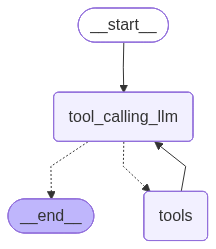

In [29]:
# Add Checkpointer
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory=graph_builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [30]:
from pprint import pprint
config={"configurable":{"thread_id":"3"}}
messages=graph_memory.invoke({"messages":"What happens if PS001 fails?"},config=config)
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What happens if PS001 fails?
================================== Ai Message ==================================

Could you please clarify the type of impact analysis you are looking for?

1. Specific type of impact (e.g., economic, environmental, operational).
2. Any specific nodes or areas you are interested in when PS001 fails.

Let me know so I can provide the most relevant information.
